In [1]:
options(warn = -1)

In [2]:
knitr::opts_chunk$set(echo = FALSE)
knitr::opts_chunk$set(warning = FALSE, message = FALSE)

In [3]:
# --- 1. Setup ---
if(!require(tidyverse)){install.packages("tidyverse")}
if(!require(lubridate)){install.packages("lubridate")}
if(!require(zoo)){install.packages("zoo")}
if(!require(randomForest)){install.packages("randomForest")}
if(!require(glmnet)){install.packages("glmnet")}

library(tidyverse)
library(lubridate)
library(e1071)
library(zoo)
library(randomForest)
library(glmnet)


Loading required package: tidyverse

-- Attaching core tidyverse packages ------------------------ tidyverse 2.0.0 --
v dplyr     1.2.0     v readr     2.1.5
v forcats   1.0.1     v stringr   1.5.1
v ggplot2   4.0.2     v tibble    3.2.1
v lubridate 1.9.4     v tidyr     1.3.2
v purrr     1.2.1     
-- Conflicts ------------------------------------------ tidyverse_conflicts() --
x dplyr::filter() masks stats::filter()
x dplyr::lag()    masks stats::lag()
i Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: zoo


Attaching package: 'zoo'


The following objects are masked from 'package:base':

    as.Date, as.Date.numeric


Loading required package: randomForest

randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attaching package: 'randomForest'


The following object is masked from 'package:dplyr':

    combine


The following object is masked from 'package:ggplot2':

    margin


Load

In [4]:
# --- 2. Load Fama-French 5-Factor Data ---
# Source: Kenneth French Data Library
# Factors: Mkt-RF, SMB, HML (Fama-French 1993), RMW, CMA (Fama-French 2015)
# All factors divided by 100 to convert from percent to decimal returns
temp <- tempfile()
url  <- "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_5_Factors_2x3_CSV.zip"
download.file(url, temp, quiet = TRUE)

raw_ff5 <- read_csv(unz(temp, "F-F_Research_Data_5_Factors_2x3.csv"), skip = 3)

ff_data <- raw_ff5 %>%
  rename(date_raw = 1) %>%
  filter(nchar(as.character(date_raw)) == 6) %>%
  mutate(
    date   = floor_date(ymd(paste0(date_raw, "01")), "month"),
    Mkt_RF = as.numeric(`Mkt-RF`) / 100,
    SMB    = as.numeric(SMB) / 100,
    HML    = as.numeric(HML) / 100,
    RMW    = as.numeric(RMW) / 100,
    CMA    = as.numeric(CMA) / 100
  ) %>%
  select(date, Mkt_RF, SMB, HML, RMW, CMA)

# --- 3. Hurst Exponent: Rescaled Range (R/S) Estimator ---
#
# ECONOMETRIC RATIONALE:
# The Hurst exponent H is the canonical measure of long memory in financial
# time series (Mandelbrot & Van Ness 1968; Lo 1991).
#   H = 0.5  =>  geometric Brownian motion (no memory, EMH null)
#   H > 0.5  =>  persistent (trending) process
#   H < 0.5  =>  mean-reverting process
#
# We use the classical R/S estimator (Hurst 1951; Lo 1991):
#   R/S = (max - min of mean-adjusted cumulative sums) / std(returns)
#   H_hat = log(R/S) / log(n)
#
# Applied here to monthly RETURNS (not price levels), since price levels
# are I(1) and their R/S statistic confounds trend with memory.
# We use a 36-month rolling window:
#   - Short enough to remain locally stationary across regime changes
#   - Long enough for R/S to converge (Lo 1991 suggests >= 32 obs minimum)
#
# ORIGINAL IMPLEMENTATION NOTE (retained for reference):
# The original code used:
#   diffs <- abs(X[3:n] - 2*X[k+1] + X[k])   # second differences of price index
#   L_n   <- sum(1 / ((n-1) * diffs))
#   H     <- log(L_n) / log(n)
# This is a sum-of-inverse-differences formula applied to a reconstructed
# price series (cumprod of 1 + returns). It has no standard citation in the
# long-memory literature and is not dimensionally consistent as an H estimator.
# Replaced with the classical R/S statistic above.
#
# NOTE: Lo (1991) proposes a modified R/S that accounts for short-run
# autocorrelation. For parsimony we use the classical version here.
# In production, consider pracma::hurstexp or the longmemo package.

compute_hurst_rs <- function(returns_vec) {
  n <- length(returns_vec)
  if (n < 36 || any(is.na(returns_vec))) return(NA_real_)

  # Mean-adjusted series
  r_demeaned <- returns_vec - mean(returns_vec)

  # Cumulative sum of mean-adjusted returns
  cum_r <- cumsum(r_demeaned)

  # R: range of the cumulative sum
  R <- max(cum_r) - min(cum_r)

  # S: standard deviation of the original return series
  S <- sd(returns_vec)

  if (S == 0 || R == 0) return(NA_real_)

  # Classical R/S Hurst estimate
  H <- log(R / S) / log(n)
  return(H)
}

# --- 4. Load Primary Data and Feature Engineering ---
#
# DATA REQUIREMENTS:
# data_ml must contain columns:
#   stock_id, date, R1M_Usd (1-month forward return — the TARGET)
#   Mom_11M_Usd (11-month momentum, months t-12 to t-2, already lagged)
#   Div_Yld, Ebit_Bv, Mkt_Cap_6M_Usd, Pb, Vol1Y_Usd
#
# LOOK-AHEAD BIAS CHECK:
# R1M_Usd is a FORWARD return — at date t it represents return[t+1].
# All feature columns must reflect information available at end of month t.
# Verify that Vol1Y_Usd and Mkt_Cap_6M_Usd are point-in-time, not updated.
# Mom_11M_Usd should be compounded over months [t-12, t-2] (standard skip-1).

load("data_ml.RData")

data_ml <- data_ml %>%
  mutate(date = floor_date(as.Date(date), "month")) %>%
  filter(date > "1999-12-31", date < "2019-01-01") %>%
  left_join(ff_data, by = "date") %>%
  arrange(stock_id, date) %>%
  group_by(stock_id) %>%
  mutate(
    # Rolling 36-month Hurst exponent applied to the RETURN series.
    # fill = NA leaves the first 35 months empty per stock.
    # NAs are handled within the rolling loop, not dropped globally here.
    Hurst = rollapplyr(R1M_Usd, width = 36, FUN = compute_hurst_rs, fill = NA)
  ) %>%
  ungroup()


New names:
* `` -> `...1`
Rows: 817 Columns: 7
-- Column specification --------------------------------------------------------
Delimiter: ","
chr (7): ...1, Mkt-RF, SMB, HML, RMW, CMA, RF

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [5]:
# --- 5. Features ---
# Follow one of the papers which suggest combining momentum with FF 5 factors
memory_features     <- c("Mom_11M_Usd", "Hurst")
accounting_features <- c("Div_Yld", "Ebit_Bv")
market_features     <- c("Mkt_Cap_6M_Usd", "Pb", "Vol1Y_Usd")
ff_features        <- c("Mkt_RF", "SMB", "HML", "RMW", "CMA")

features <- c(memory_features, accounting_features, market_features, ff_features)

formula_reg <- as.formula(paste("R1M_Usd ~", paste(features, collapse = " + ")))

In [6]:
# With Lasso, verify the feature list to see if any are zeroed out
select_top_features_lasso <- function(train_data, candidate_features, target = "R1M_Usd", 
                                      top_n = 10, alpha = 1) {
  x_mat <- as.matrix(train_data[, candidate_features])
  y_vec <- train_data[[target]]

  # Simple mean imputation
  x_mat <- apply(x_mat, 2, function(x) {
    x[is.na(x)] <- mean(x, na.rm = TRUE)
    return(x)
  })

  # Fit model
  cv_fit <- cv.glmnet(x_mat, y_vec, alpha = alpha, nfolds = 5)
  
  # Extract coefficients at lambda.min
  coefs <- coef(cv_fit, s = "lambda.min")
  
  # Convert to a tidy data frame for ranking
  coef_df <- data.frame(
    feature = rownames(coefs),
    abs_weight = abs(as.numeric(coefs))
  ) %>%
    filter(feature != "(Intercept)", abs_weight > 0) %>%
    arrange(desc(abs_weight))

  # Return only the top N names
  top_features <- head(coef_df$feature, top_n)
  
  if (length(top_features) == 0) return(candidate_features)
  return(top_features)
}

calibration_data <- data_ml %>%
  filter(date >= "2000-01-01", date <= "2004-12-31") %>%
  drop_na(all_of(features), R1M_Usd)

filtered_features <- select_top_features_lasso(calibration_data, features)
cat("LASSO-selected features (calibration 2000-2004):\n")
print(filtered_features)

LASSO-selected features (calibration 2000-2004):
 [1] "HML"            "Mkt_RF"         "SMB"            "CMA"           
 [5] "RMW"            "Hurst"          "Mom_11M_Usd"    "Vol1Y_Usd"     
 [9] "Mkt_Cap_6M_Usd" "Pb"            


In [ ]:
# --- 5. Rolling Window Execution ---
data_stock <- data_ml
window_length_years <- 5
months_in_window <- window_length_years * 12

all_dates <- sort(unique(data_stock$date))
test_dates <- all_dates[(months_in_window + 1):length(all_dates)]

predictions_df <- data.frame(
  date = as.Date(character()),
  actual = numeric(),
  pred_rf = numeric(),
  pred_ols = numeric()
)

# Initialize a counter for dropped rows
total_nas_dropped <- 0

for (i in 1:length(test_dates)) {
  current_date <- test_dates[i]

  data_stock <- data_stock %>%
  group_by(date) %>%
  mutate(R1M_Usd_rank = (rank(R1M_Usd) - 1) / (n() - 1) * 2 - 1) %>%
  ungroup()
  
  # A. Define Training/Testing Sample
  train_raw <- data_stock %>% filter(date < current_date) %>% tail(months_in_window)
  test_raw <- data_stock %>% filter(date == current_date)
  
  # --- THE PROPER DROP ---
  # Only consider the columns actually used in the model
  cols_to_check <- c("R1M_Usd", filtered_features)
  
  # Count NAs before dropping
  nas_in_this_window <- sum(!complete.cases(train_raw[, cols_to_check]))
  total_nas_dropped <- total_nas_dropped + nas_in_this_window
  
  # Filter for complete cases only
  train_data <- train_raw[complete.cases(train_raw[, cols_to_check]), ]
  test_data <- test_raw[complete.cases(test_raw[, cols_to_check]), ]
  
  # Safety Check: If we dropped too many, we can't run a reliable model
  # OLS typically needs at least (N variables + 1) observations
  min_obs_required <- length(filtered_features) + 5
  if(nrow(train_data) < min_obs_required || nrow(test_data) == 0) {
      next
  }

  # B. LASSO
  x_train_mat <- as.matrix(train_data[, filtered_features])
  y_train_vec <- train_data$R1M_Usd
  
  fit_lasso_internal <- cv.glmnet(x_train_mat, y_train_vec, alpha = 1)
  curr_coefs <- coef(fit_lasso_internal, s = "lambda.min")
  active_vars <- rownames(curr_coefs)[which(as.numeric(curr_coefs) != 0)]
  active_vars <- setdiff(active_vars, "(Intercept)")
  
  # C. Post-LASSO OLS 
  if(length(active_vars) > 0) {
      refined_formula <- as.formula(paste("R1M_Usd ~", paste(active_vars, collapse = " + ")))
      fit_ols <- lm(refined_formula, data = train_data)
      
      if(any(is.na(coef(fit_ols)))) {
          pred_ols <- rep(mean(train_data$R1M_Usd), nrow(test_data))
      } else {
          pred_ols <- predict(fit_ols, test_data)
      }
  } else {
      pred_ols <- rep(mean(train_data$R1M_Usd), nrow(test_data))
  }
  
  # D. Random Forest
  # We started by testing a node size of 5, which did not have great predictive results. 
  set.seed(42)
  fit_rf <- randomForest(formula_reg, 
                         data = train_data,
                         ntree = 200, 
                         nodesize = 1000, # originally attempted 5, returns decline in OOS testing.
                         importance = TRUE)     
  pred_rf <- predict(fit_rf, test_data)
  
  # E. Store Results
  predictions_df <- rbind(predictions_df, data.frame(
    date = current_date,
    stock_id = test_data$stock_id,
    actual = test_data$R1M_Usd,
    pred_rf = as.numeric(pred_rf),
    pred_ols = as.numeric(pred_ols)
  ))
}

# --- 6. Results Summary ---
cat("--- Data Quality Report ---\n")
cat("Total NA rows dropped during rolling windows: ", total_nas_dropped, "\n\n")

# --- 6. Results Summary ---
cat("--- Performance Summary ---\n")
mse_rf <- mean((predictions_df$pred_rf - predictions_df$actual)^2)
mse_ols <- mean((predictions_df$pred_ols - predictions_df$actual)^2)
cat("Random Forest MSE: ", round(mse_rf, 6), "\n")
cat("OLS Baseline MSE:  ", round(mse_ols, 6), "\n")

--- Data Quality Report ---
Total NA rows dropped during rolling windows:  630 

--- Performance Summary ---
Random Forest MSE:  0.032504 
OLS Baseline MSE:   0.081817 


In [ ]:
# Calculate MSE
mse_rf <- mean((predictions_df$pred_rf - predictions_df$actual)^2)
mse_ols <- mean((predictions_df$pred_ols - predictions_df$actual)^2)

# Calculate Hit Ratio (Directional Accuracy)
hit_rf <- mean(sign(predictions_df$pred_rf) == sign(predictions_df$actual))
hit_ols <- mean(sign(predictions_df$pred_ols) == sign(predictions_df$actual))

# Display Results
cat("----------------------------------\n")
cat("Random Forest MSE: ", round(mse_rf, 6), "\n")
cat("OLS Baseline MSE:  ", round(mse_ols, 6), "\n")
cat("----------------------------------\n")
cat("Random Forest Hit Ratio: ", round(hit_rf * 100, 2), "%\n")
cat("OLS Baseline Hit Ratio:  ", round(hit_ols * 100, 2), "%\n")

----------------------------------
Random Forest MSE:  0.032504 
OLS Baseline MSE:   0.081817 
----------------------------------
Random Forest Hit Ratio:  53.42 %
OLS Baseline Hit Ratio:   49.16 %


In [9]:
# Evaluation functions

# A1. Mean Squared Error (MSE) with Decomposition
compute_mse <- function(y_true, y_pred) {
  mse <- mean((y_true - y_pred)^2)
  cat("MSE (total):", round(mse, 6), "\n")
  cat("Note: cross-term -2E[yŷ] is most informative for portfolios\n")
  return(invisible(mse))
}

# A3. Out-of-Sample R2 (OOS R2)
compute_oos_r2 <- function(y_true, y_pred, include_mean_benchmark = FALSE) {
  numerator <- sum((y_true - y_pred)^2)
  denominator <- if (include_mean_benchmark) sum((y_true - mean(y_true))^2) else sum(y_true^2)
  r2 <- 1 - (numerator / denominator)
  cat("OOS R2:", round(r2, 4), "\n")
  return(invisible(r2))
}

# A4. Hit Ratio (Directional Accuracy)
compute_hit_ratio <- function(y_true, y_pred) {
  hit_ratio <- mean(sign(y_pred) == sign(y_true))
  cat("Hit ratio:", round(hit_ratio, 4), "\n")
  return(invisible(hit_ratio))
}

# E1. Evaluate OOB Error Curve
evaluate_rf_oob <- function(rf_fit, plot_curve = TRUE) {
  if (!inherits(rf_fit, "randomForest")) stop("rf_fit must be a randomForest object.")
  
  if (rf_fit$type == "regression") {
    oob_errors <- rf_fit$mse
    ylab <- "OOB Mean Squared Error"
  } else {
    oob_errors <- rf_fit$err.rate[, "OOB"]
    ylab <- "OOB Classification Error"
  }
  
  final_err <- tail(oob_errors, 1)
  stable_at <- which(abs(diff(oob_errors)) < 0.001 * final_err)[1]
  
  cat("Random Forest OOB diagnostics:\n")
  cat(" Total trees grown :", length(oob_errors), "\n")
  cat(" Final OOB error   :", round(final_err, 6), "\n")
  cat(" Approx. plateau at:", stable_at, "trees\n")
  
  if (plot_curve) {
    plot(oob_errors, type = "l", col = "steelblue", xlab = "Number of trees", 
         ylab = ylab, main = "Random Forest: OOB Error Curve")
  }
  return(invisible(oob_errors))
}

# E2. Evaluate Variable Importance
evaluate_rf_importance <- function(rf_fit, top_n = 20, plot_importance = TRUE) {
  if (is.null(rf_fit$importance)) stop("Re-train with importance=TRUE")
  
  imp_mat <- importance(rf_fit)
  imp_col <- ifelse(rf_fit$type == "regression", "%IncMSE", "MeanDecreaseAccuracy")
  
  imp_df <- data.frame(feature = rownames(imp_mat), importance = imp_mat[, imp_col])
  imp_df <- imp_df[order(imp_df$importance, decreasing = TRUE), ]
  
  print(head(imp_df, top_n))
  
  if (plot_importance) {
    top_df <- head(imp_df, top_n)
    barplot(rev(top_df$importance), names.arg = rev(top_df$feature), 
            horiz = TRUE, col = "steelblue", main = "RF Variable Importance")
  }
  return(invisible(imp_df))
}

# -----------------------------------------------------------------------------
# H1. Sharpe Ratio (standard and transaction-cost adjusted)
# -----------------------------------------------------------------------------
compute_sharpe <- function(returns_portfolio, returns_benchmark = NULL,
                           tc_per_unit_turnover = 0,
                           avg_turnover = 0,
                           annualise_factor = 12) {
  # Arguments:
  #   returns_portfolio      : numeric vector of portfolio monthly returns
  #   returns_benchmark      : optional numeric vector of benchmark returns
  #                            (for information ratio; NULL = skip)
  #   tc_per_unit_turnover   : transaction cost per unit of turnover
  #                            (Section 2 uses 0.005 as a conservative figure)
  #   avg_turnover           : average monthly turnover (from compute_turnover)
  #   annualise_factor       : multiply monthly Sharpe by sqrt of this value
  #
  # Returns: named numeric vector with Sharpe and related metrics
 
  mu    <- mean(returns_portfolio, na.rm = TRUE)
  sigma <- sd(returns_portfolio,   na.rm = TRUE)
 
  # Raw Sharpe (monthly)
  sharpe_raw <- mu / sigma
 
  # TC-adjusted Sharpe: subtract annualised costs from numerator (Eq. 4, Section 2)
  tc_annual  <- tc_per_unit_turnover * avg_turnover * annualise_factor
  sharpe_tc  <- (mu - tc_per_unit_turnover * avg_turnover) / sigma
 
  # Annualised versions
  sharpe_raw_ann <- sharpe_raw * sqrt(annualise_factor)
  sharpe_tc_ann  <- sharpe_tc  * sqrt(annualise_factor)
 
  cat("Sharpe ratio diagnostics:\n")
  cat("  Avg monthly return   :", round(mu,    4), "\n")
  cat("  Monthly volatility   :", round(sigma, 4), "\n")
  cat("  Sharpe (monthly)     :", round(sharpe_raw, 4), "\n")
  cat("  Sharpe (annualised)  :", round(sharpe_raw_ann, 4), "\n")
  cat("  Avg turnover         :", round(avg_turnover, 4), "\n")
  cat("  TC per unit turnover :", tc_per_unit_turnover, "\n")
  cat("  TC-adj Sharpe (ann)  :", round(sharpe_tc_ann, 4), "\n")
 
  if (!is.null(returns_benchmark)) {
    excess     <- returns_portfolio - returns_benchmark
    info_ratio <- mean(excess, na.rm = TRUE) / sd(excess, na.rm = TRUE)
    cat("  Information ratio    :", round(info_ratio * sqrt(annualise_factor), 4), "\n")
    cat("  Tracking error (ann) :", round(sd(excess) * sqrt(annualise_factor), 4), "\n")
  }
 
  return(invisible(c(sharpe_raw     = sharpe_raw,
                     sharpe_raw_ann = sharpe_raw_ann,
                     sharpe_tc      = sharpe_tc,
                     sharpe_tc_ann  = sharpe_tc_ann)))
}

In [10]:
# --- Evaluation for Random Forest Predictions ---
cat("--- Random Forest Performance ---\n")
compute_mse(
  y_true = predictions_df$actual, 
  y_pred = predictions_df$pred_rf
)

compute_oos_r2(
  y_true = predictions_df$actual, 
  y_pred = predictions_df$pred_rf, 
  include_mean_benchmark = TRUE  # Compare against a historical mean return
)

compute_hit_ratio(
  y_true = predictions_df$actual, 
  y_pred = predictions_df$pred_rf
)

# --- Evaluation for OLS Baseline ---
cat("\n--- OLS Baseline Performance ---\n")
compute_mse(predictions_df$actual, predictions_df$pred_ols)
compute_oos_r2(predictions_df$actual, predictions_df$pred_ols, include_mean_benchmark = TRUE)
compute_hit_ratio(predictions_df$actual, predictions_df$pred_ols)

--- Random Forest Performance ---
MSE (total): 0.032504 
Note: cross-term -2E[y<U+0177>] is most informative for portfolios
OOS R2: -0.0474 
Hit ratio: 0.5342 

--- OLS Baseline Performance ---
MSE (total): 0.081817 
Note: cross-term -2E[y<U+0177>] is most informative for portfolios
OOS R2: -1.6364 
Hit ratio: 0.4916 


Random Forest OOB diagnostics:
 Total trees grown : 200 
 Final OOB error   : 0.013277 
 Approx. plateau at: 7 trees
                      feature importance
RMW                       RMW  6.9869008
Mkt_Cap_6M_Usd Mkt_Cap_6M_Usd  1.3526815
HML                       HML  1.0884238
Ebit_Bv               Ebit_Bv  1.0211454
SMB                       SMB  0.2143305
Vol1Y_Usd           Vol1Y_Usd  0.1287453
Hurst                   Hurst -0.5839074
Div_Yld               Div_Yld -0.6107175
Pb                         Pb -1.1961667
Mom_11M_Usd       Mom_11M_Usd -1.8562507


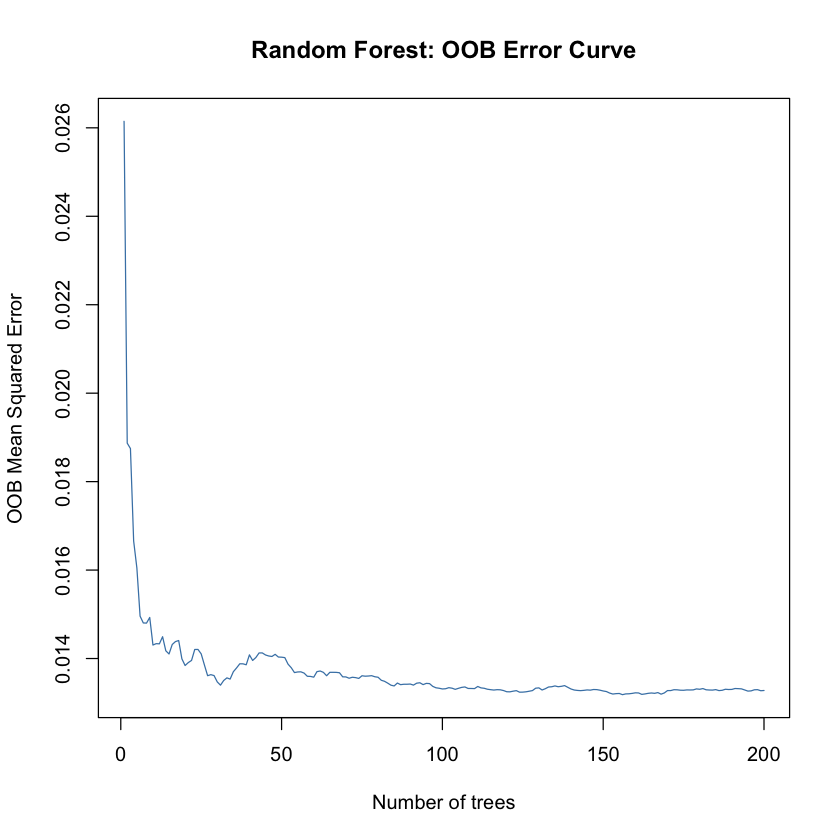

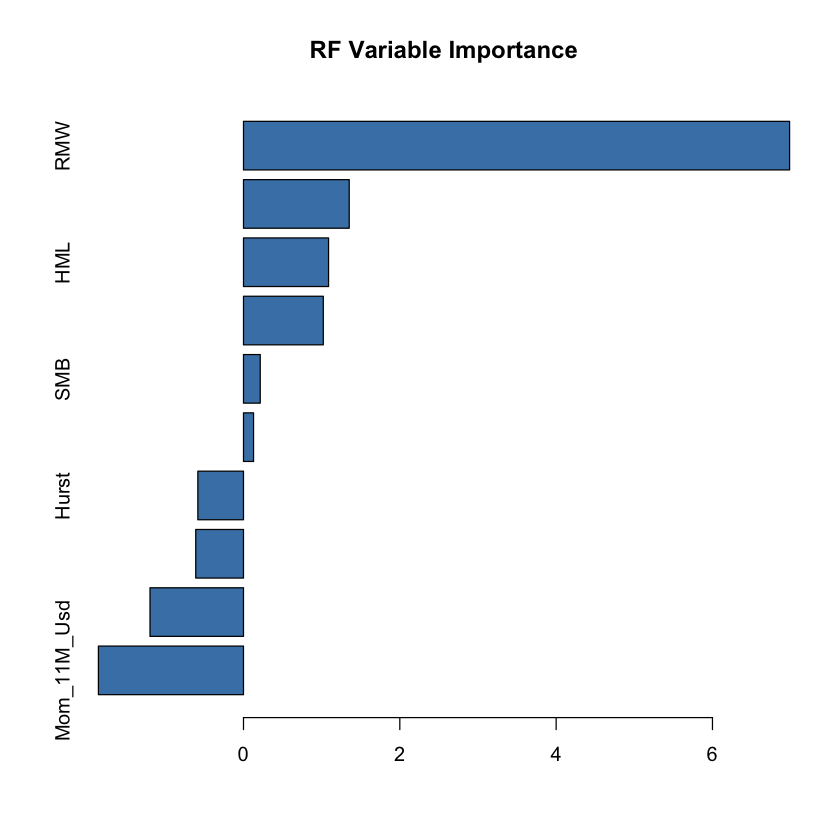

In [11]:
# 1. Visualize the OOB Error Curve
# This helps check if 200 trees were sufficient for the error to stabilize.
evaluate_rf_oob(fit_rf)

# 2. Extract and Plot Variable Importance
# This identifies which stock characteristics were most predictive in the latest window.
# (Ensure importance = TRUE was used during training)
rf_importance_results <- evaluate_rf_importance(
  fit_rf, 
  top_n = 10, 
  plot_importance = TRUE
)

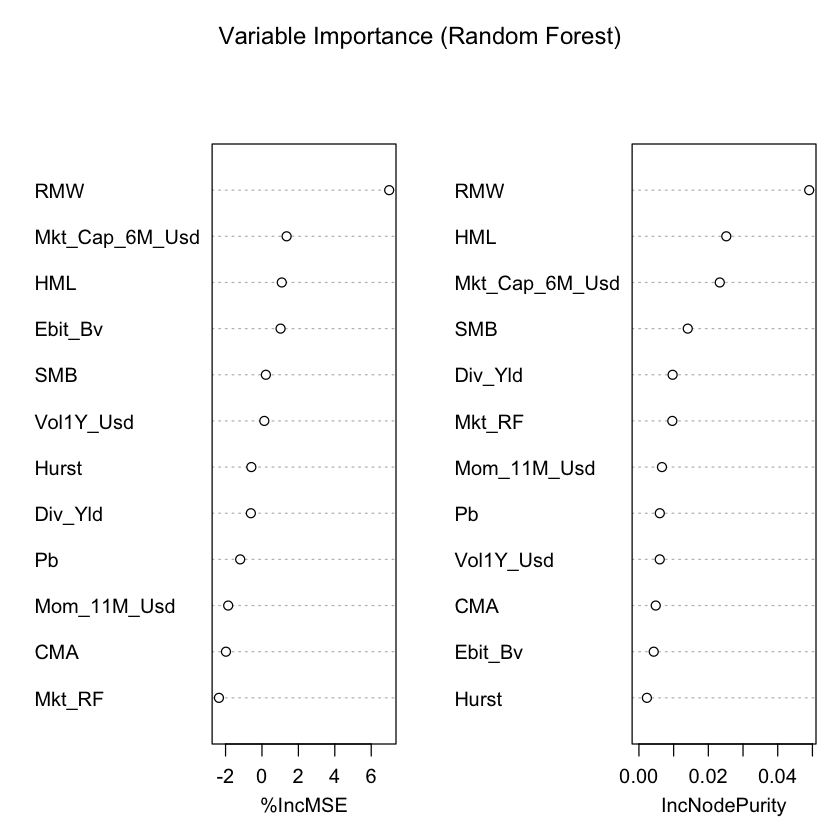

In [12]:
varImpPlot(fit_rf, main = "Variable Importance (Random Forest)")


In [13]:
# save data for combined evaluation
RF_PREDICTIONS_PATH <- "preds/rf_preds.rds"
saveRDS(predictions_df, file = RF_PREDICTIONS_PATH)
